# Modelling and Running Bitcoin VWAP Strategy with O-U Process

## Calling Bitcoin data

,Time,open,high,low,close,volume,numTrades,takerbuy_base
0,2017-12-31 04:59:03.552,12924.54,12957.99,12875.23,12900.27,19.750157,170.0,9.008100
1,2017-12-31 05:03:25.696,12909.28,12923.40,12800.00,12861.00,14.698302,213.0,7.444182
2,2017-12-31 05:05:36.768,12861.00,12976.00,12859.59,12965.60,30.501879,202.0,18.989504
3,2017-12-31 05:09:58.912,12968.00,13002.90,12902.37,12948.97,24.652646,274.0,16.315017
4,2017-12-31 05:12:09.984,12926.23,12950.00,12904.23,12937.37,16.027044,144.0,12.823083
...,...,...,...,...,...,...,...,...
1148067,2024-07-24 14:51:41.952,66946.01,66946.01,66864.00,66879.19,38.180460,2830.0,10.360890
1148068,2024-07-24 14:53:53.024,66879.19,66944.82,66788.00,66920.00,60.679110,10752.0,35.528450
1148069,2024-07-24 14:56:04.096,66920.00,66920.00,66760.00,66760.01,105.677260,3776.0,42.355380
1148070,2024-07-24 15:00:26.240,66760.01,66812.00,66701.00,66730.00,68.127690,4295.0,24.468740


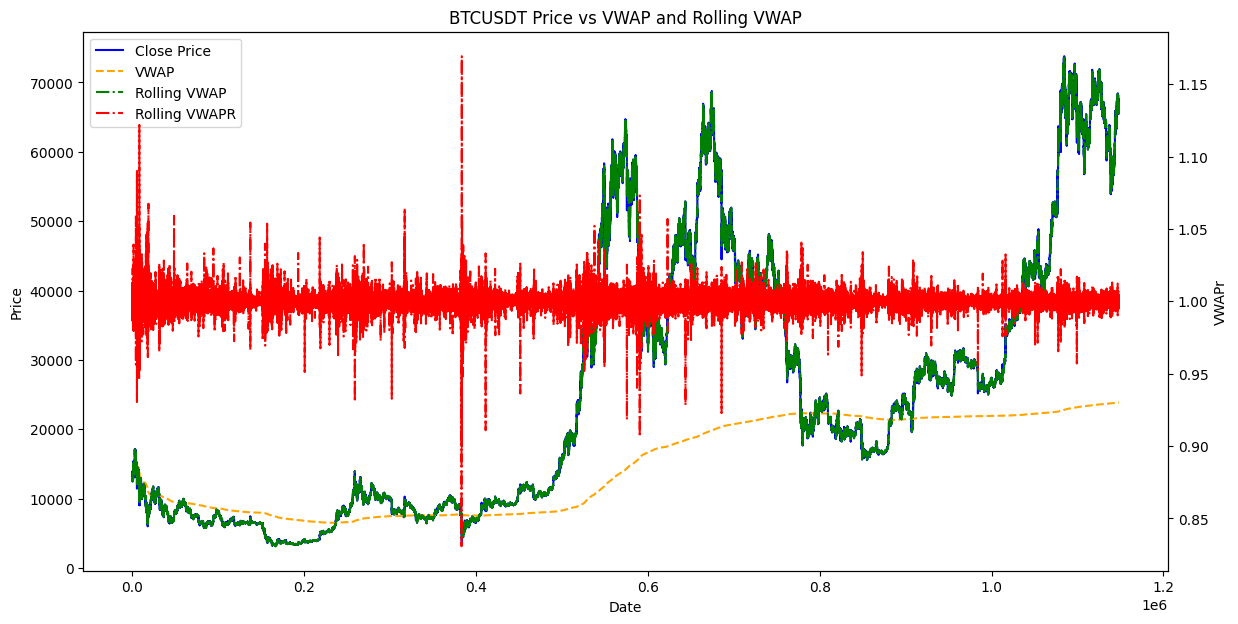

## Check VWAPr has serial correlation for further framework

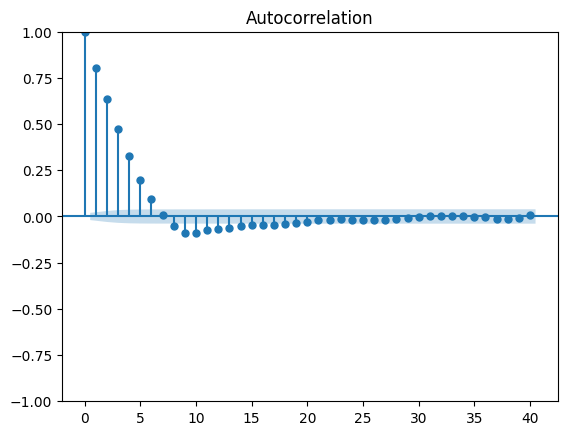

As the VWAPr shows the significant autocorrelation of its values, we can apply the O-U process for the prices.

Let's say we are modelling VWAPr of Bitcoin prices. So, In here, we assume the Bitcoin VWAPr follows O-U Process. 











$P_{i,t} =  (1-\phi)E_0[P_{i, T_i}] + \phi P_{i,t-1} + \sigma \epsilon_{i,t}$

This equation represents a type of autoregressive model with a mean-reverting component. 
First component represents the price of asset at time t, i-th trading opportunity and the $E_0[P_{i, T_i}]$ shows the expected price at terminal time, which represents
some future expected value(can be called as fundamental value or a equilibirum price)
$\phi$ is the autoregressive parameter which dictates the weight given to the previous time step $P_{i, t-1}$. It ranges between 0 and 1, determining how much the price depends on the past.

i-th trading success depends on the speed of $P_{i,0}$ reverting to $E_{0}[P_{i,T_i}]$. So $\pi = m_i(P_{i,t} - P_{i,0})$

The i-th opportunity's success can be modeled;

$\frac{1}{m_{i}} \pi_{i,t} = (1-\phi)E_0[P_{i, T_i}] - P_{i,0} + \phi P_{i,t-1} + \sigma \epsilon_{i,t}$

According to Bailey and Lopez de Prado(2013), The distribution of this process follows the Gaussian distribution with specific parameters.





ADF Statistic: -24.52128613690776
p-value: 0.0


Estimated O-U Parameters: theta = 0.49999891167781463, mu = 1.0000099947123962, sigma = 0.002469468602528599


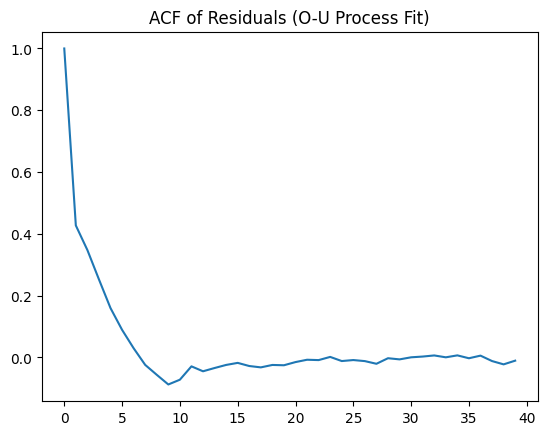

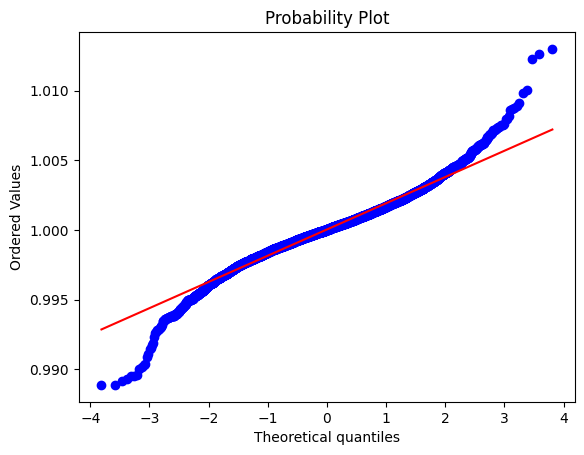

In [121]:
# Calculate predicted VWAPr values using the fitted O-U process
predicted_vwapr = vwapr_series[:-1] + theta_est * (mu_est - vwapr_series[:-1]) * dt

# Calculate residuals
residuals = vwapr_series[1:] - predicted_vwapr

residuals

#residuals = residuals.dropna()
# Check ACF of residuals to verify model fit
acf_residuals = sm.tsa.acf(residuals)
plt.plot(acf_residuals)
plt.title("ACF of Residuals (O-U Process Fit)")
plt.show()

import scipy.stats as stats

# Q-Q plot to check normality of VWAPr
stats.probplot(vwapr_series, dist="norm", plot=plt)
plt.show()


보면 알겠지만.. Residual의 Fat-tail event가 자주 발생한다. 그럼 normal distribution 하에서는 해당 이벤트들이 잘 안잡힐거다. 그럼 Fat-tail event를 추가하기 위해 기존 O-U process에 Fat-tail event를 추가하는 건 어떨까?

기존 Residual이 Norm dist를 따르기보다는 Fat-tail event를 보여준다면, Error term distribution에 Fat-tail이 잘 나타난 형태가 잘 맞는다는 것을 의미함.
그래서 Student t-distribution을 적용시키고, 해당 형태에서 Residual 값을 살펴봄.


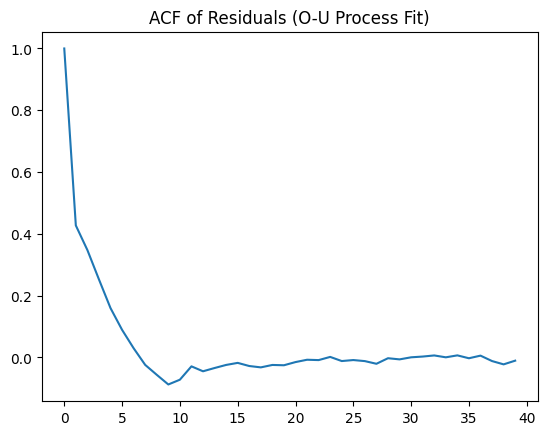

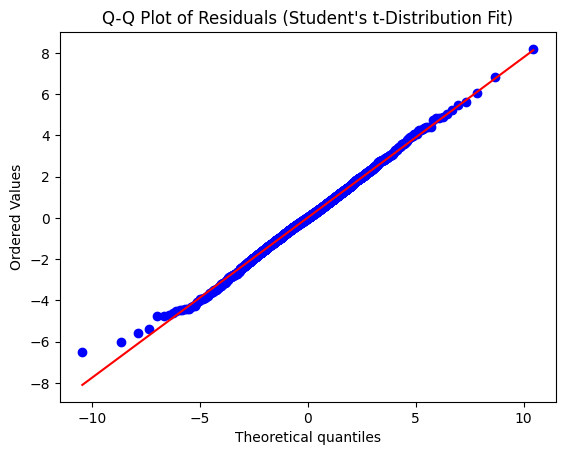

위 결과에서 볼 수 있듯이, 잘 맞음

# Trading Strategy

결국 내가 한것은 VWAPr이 O-U Process 를 따른다고 가정한 것이다.
실제 거래에서는 Price를 거래하기 때문에, 이 모델링한 VWAPr를 어떻게 잘쓸것인가..에 대한 고민을 해야함.

결국 VWAPr이 특정한 형태(O-U Process)로 모델링이 된다는 말은, 우리가 특정 저점에서 매수와 매도를 반복할 수 있다는 것을 의미한다.
그러나 이게 실제로는 수익이 될까? 이 부분은 테스팅을 해봐야 할듯.
비트코인 시장이 워낙 모멘텀이 강한 시장이다보니.. 현재 테스팅 진행전에 우려는 되지만, 후에 필터링을 추가하는 방법으로 생각해봐야할 부분인듯.

일단 VWAPr이 O-U Process를 따른다고 말 할수 있다. Fat-tail 현상이 조금 올라오긴하지만..시뮬레이션에 Student t-distribution을 추가하고 살펴보면 될듯

O-U process를 따르는 VWAPr 에서 규칙성을 파악하는 것이 먼저인듯.

투자 전략 S가 i=1,...,I 기회 또는 베팅을 실행한다고 가정해보자. 기회 i에서 S는 증권 X의 m 단위의 포지션을 취하며 m은 $-\infty$ 에서 $\infty$ 값을 가질 수 있다.
같은 기회에 진입한 거래의 가격은 $m_i P_{i,0}$ 으로 매겨지고, i번재 기회에서 진입가격 X 취한 포지션 크기를 의미한다. 이는 t 거래후의 시장에서 현금화 하게 되면 $m_i P_{i,t}$ 가격으로 현금화가 된다. 이런 이유로 t 거래후의 기회 i의 수익/손실은 $\pi_{i,t} = m_i(P_{i,t} - P_{i,0})$ 으로 계산할 수 있다.

여기서 우리는 VWAPr 을 사용하기 때문에 조금은 다르게 접근해야 할듯?
일단은 VWAPr이 O-U Process를 따른다고 가정하면, 사실 요걸 모델링 했을 때, 특정 시점에서 가격이 과거 거래량에 기반한 평균 가격으로 얼마나 회귀할지, 얼마나 더 변동할지에 대한 통계적 예측이 가능하다. 이러한 시장의 불확실성을 수학적으로 모델링함으로써 평균 회귀 성향을 반영하며, 이로 인해 단순한 고점/저점 매도가 아닌 정교한 트레이딩 전략을 설계할 수 있음.

간략화를 위해 P는 VWAPr로 변환해서 생각하도록 하겠음

결국 VWAPr에 대한 이산 올스타인-울렌백 프로세스를 가정하게 된다면,

$P_{i,t} = (1-\phi)E_0[P_{i,T_i}] + \phi P_{i,t-1} + \sigma \epsilon_{i,t}$ 으로 작성할 수 있다.

여기서 랜덤쇼크는 IID 분포의 $\epsilon_{i,t} \sim N(0,1)$ 이다. 이 프로세스의 시드값은 P_{i,0} 기회 i에 의한 모교수준이 $E_0[P_{i,T_i}]$ 이고 $\phi$는 $P_{i,0}$이 $E_0[P_{i,T_i}]$ 로의 수렴속도를 결정한다. 결국 기회 i의 성과는 다음 프로세스에 의해 특성화 된다.

$\frac{1}{m} \pi_{i,t} = (1-\phi)E_0[P_{i,T_i}] - P_{i,0} + \phi P_{i,t-1} + \sigma \epsilon_{i,t}$

Bailey 와 Lopez de Prado는 위의 식 분포가 다음과 같은 파라미터를 가진 가우시안 분포라는 것을 증명했다 (2013)


$\pi_{i,t} \sim N[m_i((1-\phi)E_0[P_{i,T_i}] \sum^{t-1}_{j=0}\phi^j - P_{i,0}), m^2_i \sigma^2 \sum^{t-1}_{j=0} \phi^2j]$

정상성의 필요 충분 조건은 $\phi \in (-1,1) $ 이다. 입력 파라미터 $[\sigma, \phi]$ 집합과 기회 i와 연관된 초기조건 $[P_{i,0}, E_0[P_{i,T_i}]]$ 이 주어질 때 OTR이 존재하는가를 찾는 문제이다. 이와 유사하게 전략 S가 수익목표를 예측한다면 최적 손절 값을 계산할 수 있는가?

이걸 계산할 수 있다면 백테스팅은 필요 없어서 거래 규칙의 과적합 문제를 피할 수 있다.

요걸 수치적으로 결정하려면 O-U 프로세스를 가정한 가격에 대한 식을 선형화한 뒤 입력 파라미터 값을 다음과 같이 추정한다.


$P_{i,t} = E_0[P_{i,T_i}] + \phi(P_{i,t-1} - E_0[P_{i, T_i}]) + \xi_t$


$$
X = \begin{bmatrix}
P_{0,0} - E_0[P_{0,T_0}] \\
P_{0,1} - E_0[P_{0,T_0}] \\
\vdots \\
P_{I,T-1} - E_0[P_{I,T}]
\end{bmatrix}
\quad
Y = \begin{bmatrix}
P_{0,1} \\
P_{0,2} \\
\vdots \\
P_{I,T}
\end{bmatrix}
\quad
Z = \begin{bmatrix}
E_0[P_{0,T_0}] \\
E_0[P_{0,T_0}] \\
\vdots \\
E_0[P_{I,T}]
\end{bmatrix}
$$

위 선형화 된 식에 OLS를 적용하면 원시 O-U 파라미터를 다음과 같이 계산할 수 있다.

$\hat{\phi} = \frac{COV[Y,X]}{COV[X,X}$ <br>
$\hat{\xi} = Y-Z-\hat{\phi}X$ <br>
$\hat{\sigma} = \sqrt{COV[\hat{\xi}_t, \hat{\xi}_t, }]$



** 그러나 Fat-tail event를 찾기 위해 OLS 보다는 MLE 방식이 추정이 더 잘 된다. <br>
** 그러나 Student t-distribution 으로 측정할 시 파라미터 값들의 불안정성이 매우 커짐. <br>
** 따라서 기존 O-U process를 OLS로 추정하고, Degrees of freedom of 5 를 적용시킨 Student t-distribution을 적용해서 시뮬레이션을 하자



OUParams(phi=0.19404506485265005, gamma=1.000040722673005, sigma=0.0011301493776285632)

위 방식은 선형화 된 식에서 O-U Process의 파라미터 값을 추정한 것. 보면 알겠지만 Phi 값이 0과 1 사이이며, 우리가 예상한 바와 같이 [이론적으로] 감마 값은 1로 회귀하게 된다.

Estimated OU parameters: OUParams(phi=0.998166271759208, gamma=1.018206357508056, sigma=3.587344422020418, df=5.0)


O-U Process를 Student t-distribution을 가정하고 파라미터 추정을 하면 어떨까? 
phi값이 1에 가깝게 나오고, 감마값은 제한을 두었기 때문에 1에 근접하게 나오지만, 변동성 값이 매우 크게 나온다. 이 경우는
사실 숫자가 Mean-reverting 하기 어렵다고 생각하는 것이 맞음.

결국 추정의 안정성..을 생각해봤을때 선형화 된 식을 OLS로 구하고, 해당 식에 Student t-distribution만 추가해서 시뮬레이션을 돌리는 것이 맞아보임.
기존 OLS 추정 파라미터갑을 사용하겠음.

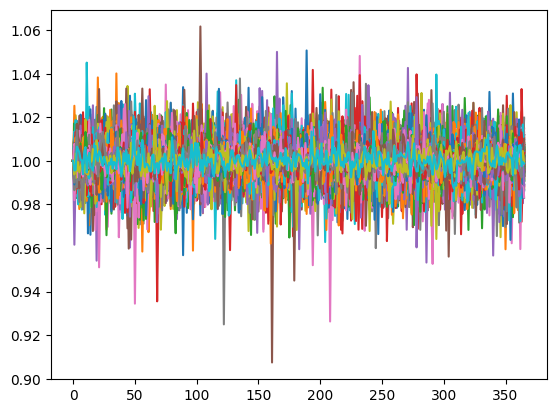

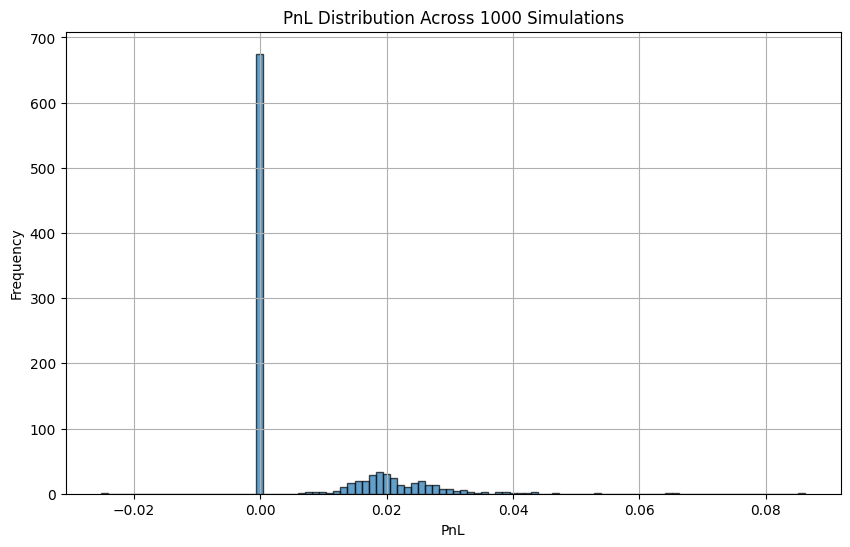

Mean PnL: 0.71%
Standard Deviation of PnL: 1.14%
Sharpe Ratio: 0.62


나름..비슷해보이지만, 극단값이 자주 일어나는 비트코인 시장과 다른 모습을 보이는 건 어쩔 수 없는 듯 하다. 아무래도 다른 상황을 시뮬레이션 해보려면, Sigma 값을 늘려서 테스트를 해봐야 할듯 싶다. 예를 들면 이런식으로? [결국 하방에서 잡아서 상단에서 파는 전략이기 때문에, 상단값으로 튀어 오르는 것은 크게 생각하지 않아도 될듯]

위는 단일 예시로 테스팅을 했으니, 이제 그리드를 만들어 히트맵을 볼 순서다.

이후에는, 손절과 이익 실현 쌍의 격자를 만든다. 시뮬레이션에서 중요한 것은 O-U Process를 따르는 격자쌍에서,
최대한 비슷한 가격흐름을 뽑는 것이다. Marcos Lopez de Prado 박사는 Half life가 $\tau = -\frac{log[2]}{log[\phi]}$ 인 것을 증명했기 때문에 해당 값을 half-life로 사용하도록 하겠다


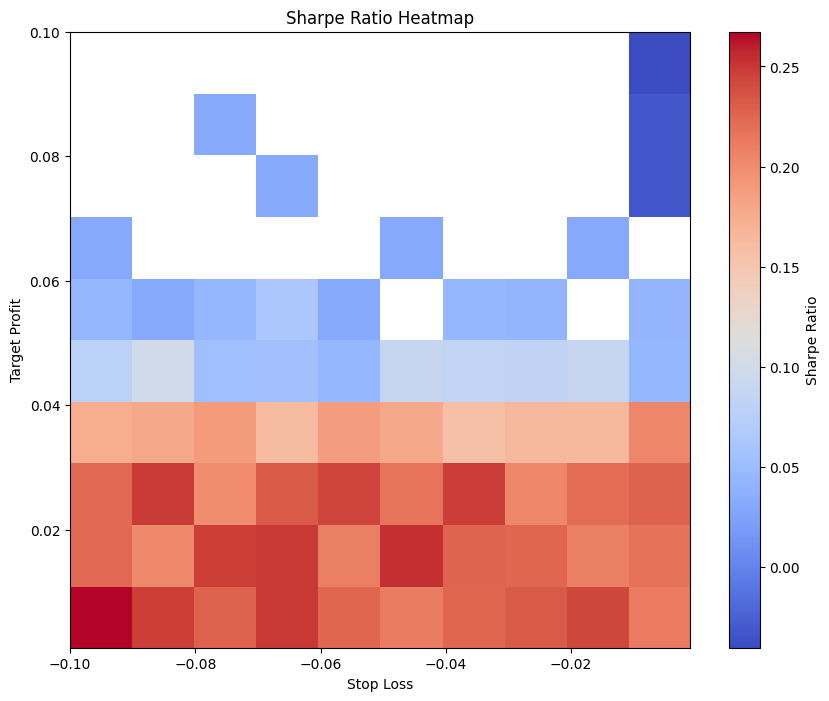

Mean PnL Grid:
 [[ 1.41900906e-03  1.28285040e-03  1.08388610e-03  1.28636625e-03
   1.10741390e-03  1.04815785e-03  1.07042301e-03  1.10621373e-03
   1.13909448e-03  1.20715614e-03]
 [ 1.04328890e-03  8.41952638e-04  1.33726869e-03  1.35594466e-03
   9.87647594e-04  1.37494127e-03  1.09705936e-03  1.00753606e-03
   9.29685161e-04  9.91694396e-04]
 [ 1.23368677e-03  1.53639434e-03  9.93089479e-04  1.34868287e-03
   1.49025655e-03  1.20410026e-03  1.55743938e-03  1.10898795e-03
   1.22221410e-03  1.31222551e-03]
 [ 1.16330011e-03  1.14516927e-03  1.33522996e-03  9.19419765e-04
   1.48926425e-03  1.18071699e-03  8.72651217e-04  9.58229247e-04
   9.39737144e-04  1.43469699e-03]
 [ 2.94524149e-04  4.78756966e-04  1.52589540e-04  1.41703379e-04
   9.26672492e-05  3.84798951e-04  3.31460944e-04  3.42440100e-04
   4.02006473e-04  9.12867014e-05]
 [ 1.14204508e-04  5.88291167e-05  1.14910038e-04  2.38697429e-04
   6.34370269e-05  0.00000000e+00  1.13349082e-04  1.51278996e-04
   0.00000000e+00

위 시뮬레이션은 VWAPr이 0.95가 되는 시점에서 어떤 값을 타겟 프로핏 / 손절값으로 지정할 것인지, 그것에 따라 VWAPr 값만을 가지고 트레이딩 하는 것이 어느정도의 SR값을 가지는지 추정하는 것이다. 결과적으로, 시뮬레이션에 의하면, 위와 같은 파라미터 값(비트코인으로부터 뽑아낸 값)들을 가진 O-U process는 "일반적인 상황" 에서는 대부분 밑의 TP/SL 값을 가진 설정값에서 잘 움직임. 위 값을 가지고 실제로 돌려보면 다음과 같이 결과가 나온다.

Mean PnL: 0.68%
Standard Deviation of PnL: 3.47%
Sharpe Ratio: 0.20


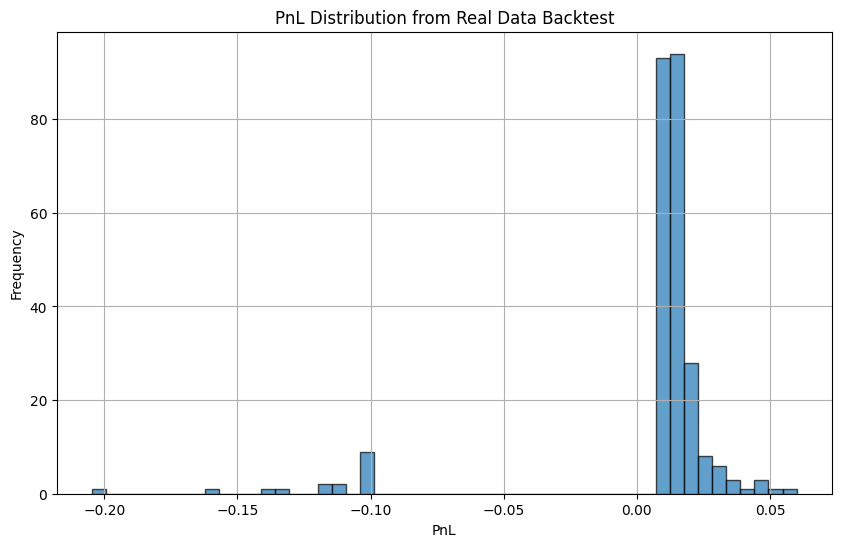

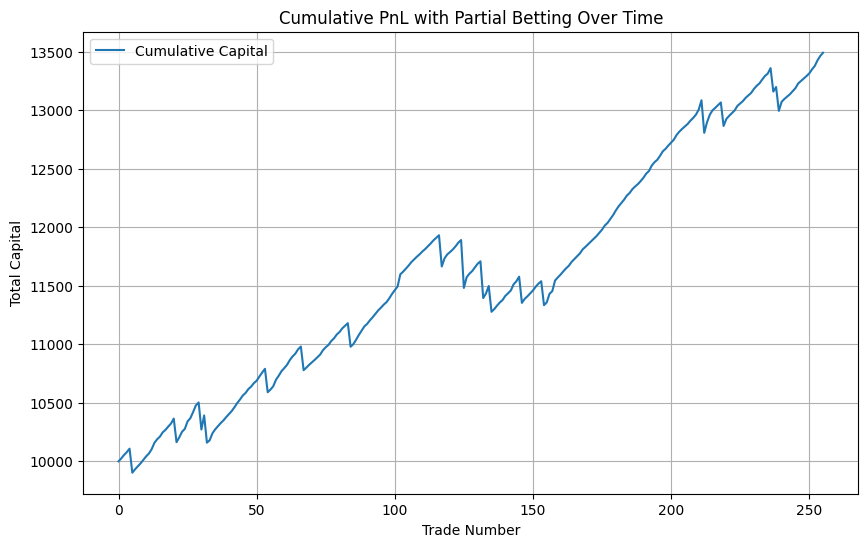

Final cumulative capital: 13491.94


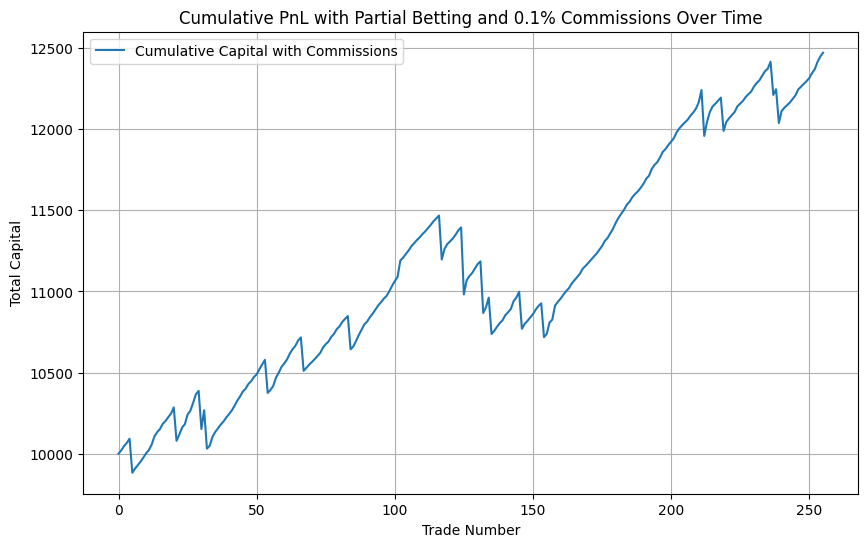

Final cumulative capital: 12471.94


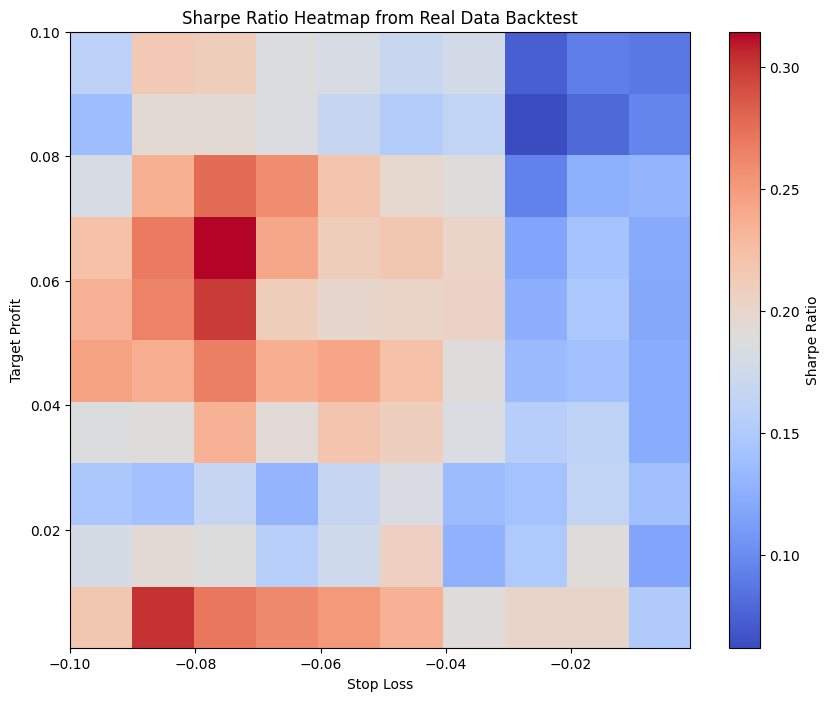

Mean PnL Grid:
 [[0.00545191 0.00633087 0.00609535 0.0058204  0.00534476 0.00496404
  0.00408259 0.00415009 0.0038267  0.00269883]
 [0.00671475 0.00666442 0.00650859 0.00537685 0.00562304 0.006008
  0.00367704 0.0039357  0.00437633 0.00234864]
 [0.00743627 0.00678345 0.00767348 0.00593416 0.00699125 0.0071075
  0.00497    0.004671   0.00467439 0.00326608]
 [0.01098252 0.01075173 0.01239767 0.01001236 0.01046375 0.00931355
  0.00774082 0.00584249 0.00527294 0.00310784]
 [0.01616552 0.01490525 0.0158936  0.01370474 0.01319906 0.01144073
  0.00892031 0.00576516 0.00512637 0.00340575]
 [0.01759056 0.01852116 0.01980969 0.0137344  0.01236535 0.01174841
  0.01074415 0.00592822 0.00594635 0.00360045]
 [0.01842788 0.02056517 0.02282122 0.01719465 0.01412457 0.01366673
  0.01161891 0.00597352 0.00620372 0.00390037]
 [0.01677757 0.02035474 0.02245572 0.02015913 0.01602095 0.01366999
  0.01191597 0.00518284 0.00588529 0.00461985]
 [0.01368125 0.01809722 0.01729629 0.01569744 0.01338021 0.01137034

# 결론

사실 실제 SR 값을 최대치로 늘리는 값은 다른 값에 있다. 그러나, 비트코인 VWAPr이 O-U Process를 따른다면, 해당 값은 "일반적인 상황"에서 작동하는 것이 아닌, 지난 2018년부터 2024년 사이의 상황에 맞춘 것이며, 따라서 해당 값에 따라 전략을 상용화시키면 앞으로의 시장 상황에 맞지 않을 가능성이 큼.

결과적으로 우리는 일반적인 O-U Process 상에서 돌아가는 시장 상황에서는 하단 부분값을 이용하는 것이 맞다고 보여짐.